# 0. README

1. Source of the code: [Git to YouTubeVideo](https://github.com/ytdeepia/Autoencoders/blob/main/Part2/mnist_ae.ipynb)
2. Video with AutoEnc visualization [Autoencoders | Deep Learning Animated](https://www.youtube.com/watch?v=hZ4a4NgM3u0)

# 1. Install & Import dependencies

In [ ]:
%pip install torch torchvision torchaudio

In [1]:
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# 2. Model of the autoencoder

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Use Sigmoid for final layer to get output in range [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
    def get_latent_vector(self, x):
        return self.encoder(x)

# 2. Load the MNIST dataset

In [4]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# 3. Do training

In [5]:
# Model, Loss Function, Optimizer
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        
        # Forward pass
        output = model(img)
        loss = criterion(output, img)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training finished!")

Epoch [1/20], Loss: 0.0557
Epoch [2/20], Loss: 0.0437
Epoch [3/20], Loss: 0.0341
Epoch [4/20], Loss: 0.0414
Epoch [5/20], Loss: 0.0337
Epoch [6/20], Loss: 0.0402
Epoch [7/20], Loss: 0.0340
Epoch [8/20], Loss: 0.0365
Epoch [9/20], Loss: 0.0317
Epoch [10/20], Loss: 0.0343
Epoch [11/20], Loss: 0.0387
Epoch [12/20], Loss: 0.0314
Epoch [13/20], Loss: 0.0350
Epoch [14/20], Loss: 0.0281
Epoch [15/20], Loss: 0.0328
Epoch [16/20], Loss: 0.0297
Epoch [17/20], Loss: 0.0327
Epoch [18/20], Loss: 0.0311
Epoch [19/20], Loss: 0.0299
Epoch [20/20], Loss: 0.0316
Training finished!


# 4. Inference the model

In [7]:
# Get some test images
images, _ = next(iter(test_loader))
images = images.to(device)

# Forward pass through the autoencoder
output = model(images)

In [8]:
# Function to show images
def imshow(img, title):
    img = img.cpu()  # Move the tensor to CPU
    npimg = img.numpy()
    plt.imshow(npimg, cmap='gray')
    plt.title(title)
    plt.show()

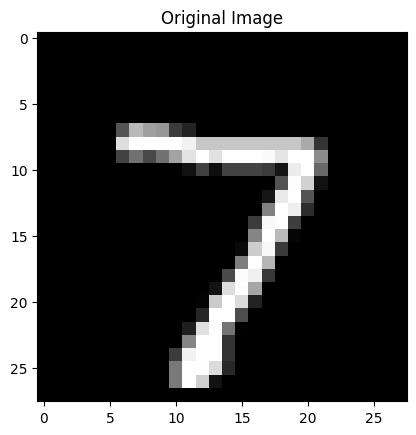

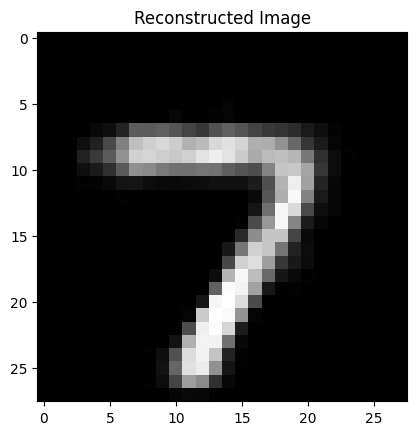

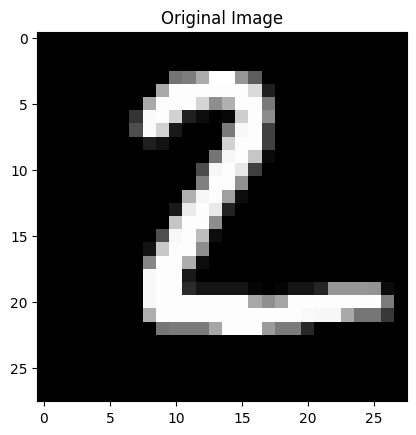

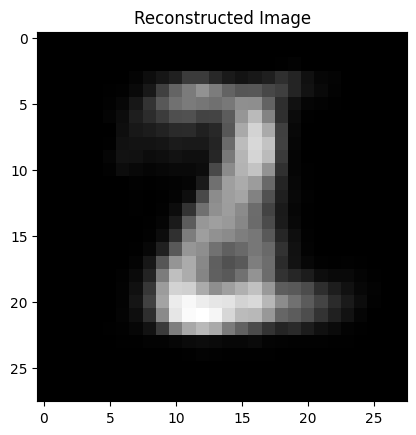

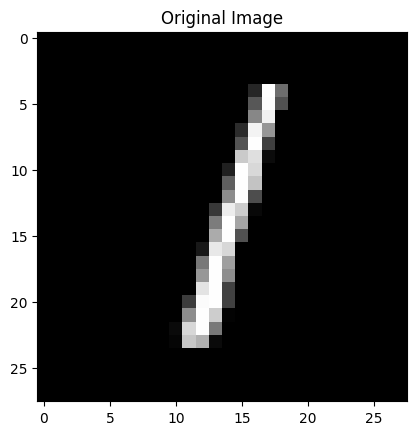

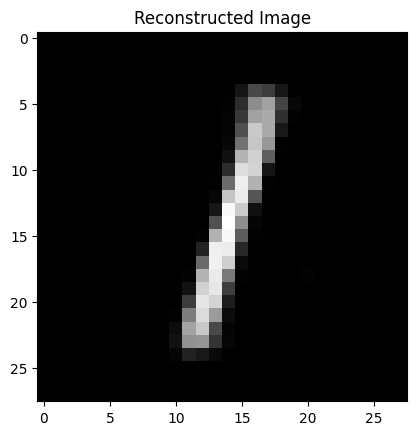

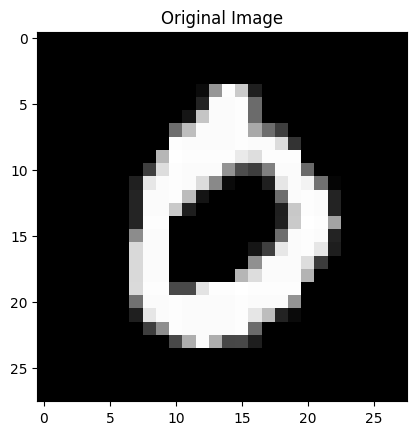

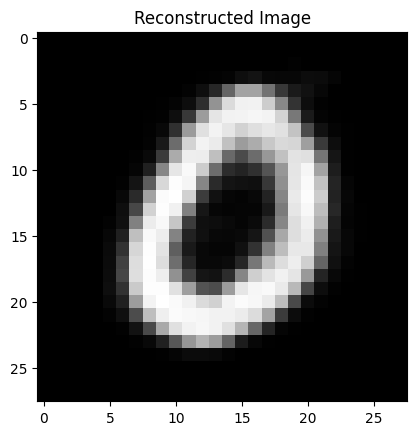

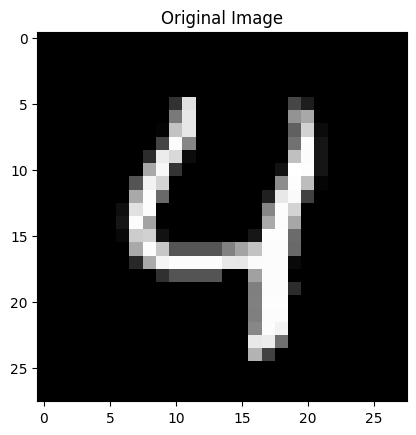

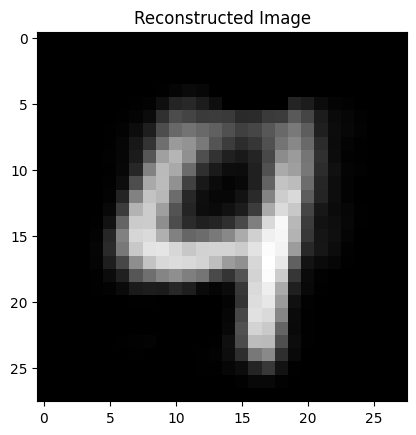

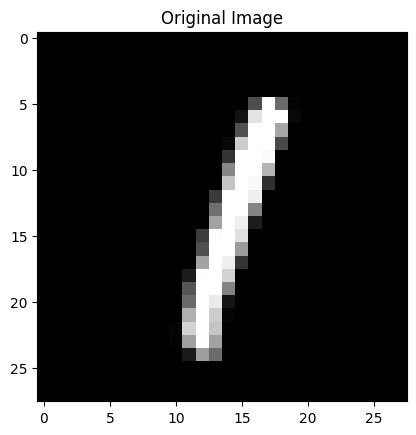

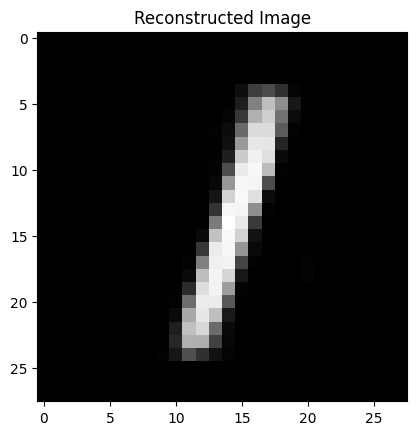

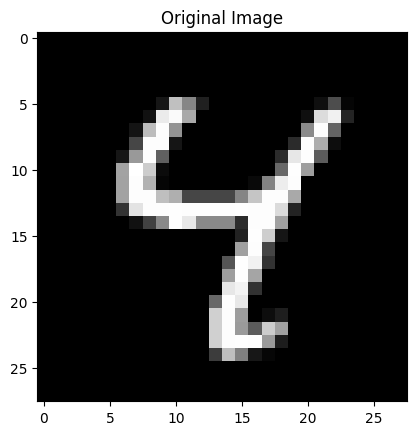

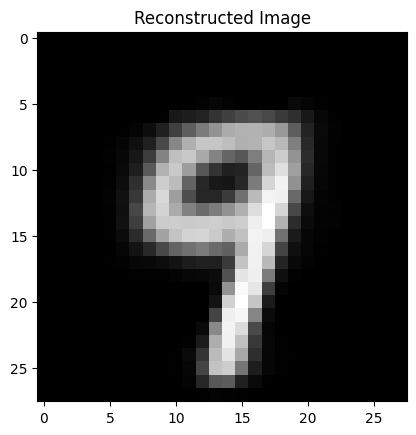

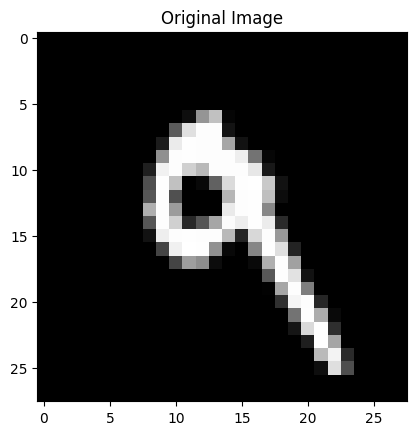

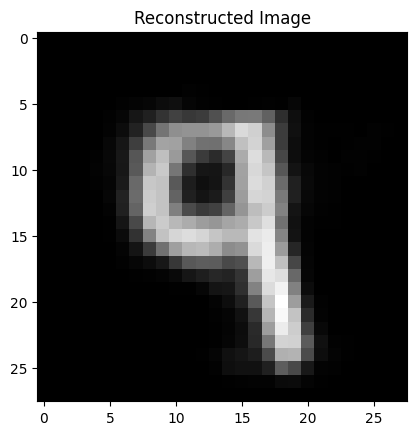

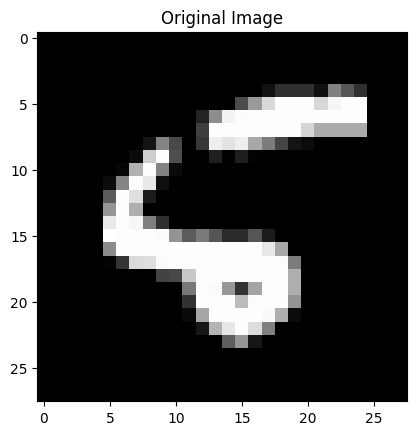

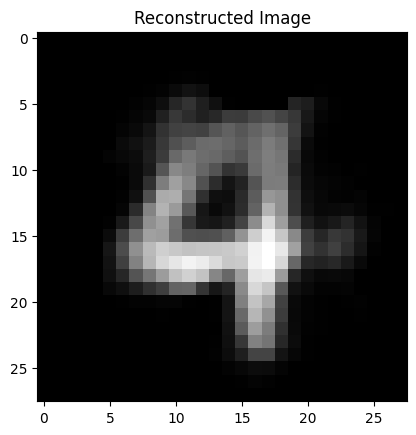

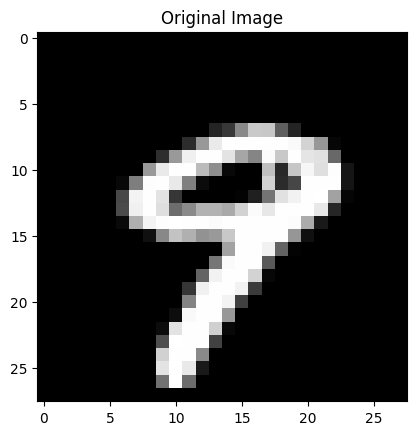

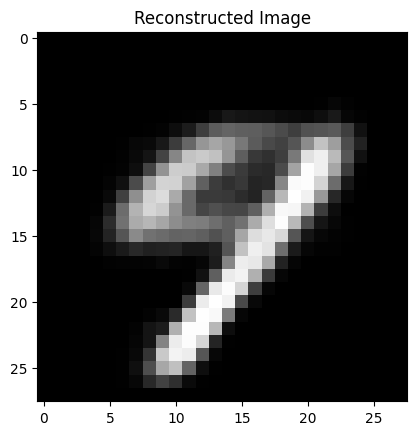

In [9]:
# Create directory to save images if it doesn't exist
# os.makedirs('images/mnist', exist_ok=True)

# Display and save original and reconstructed images
for i in range(len(images)):
    # Original images
    imshow(images[i].view(28, 28), title='Original Image')
    # save_image(images[i].view(1, 28, 28), f'images/mnist/original_{i}.png')
    
    # Reconstructed images
    imshow(output[i].view(28, 28).detach(), title='Reconstructed Image')
    # save_image(output[i].view(1, 28, 28).detach(), f'images/mnist/reconstructed_{i}.png')

# 5. Looking on latent space

D:\documents\python_projects\bulding_ML_models\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


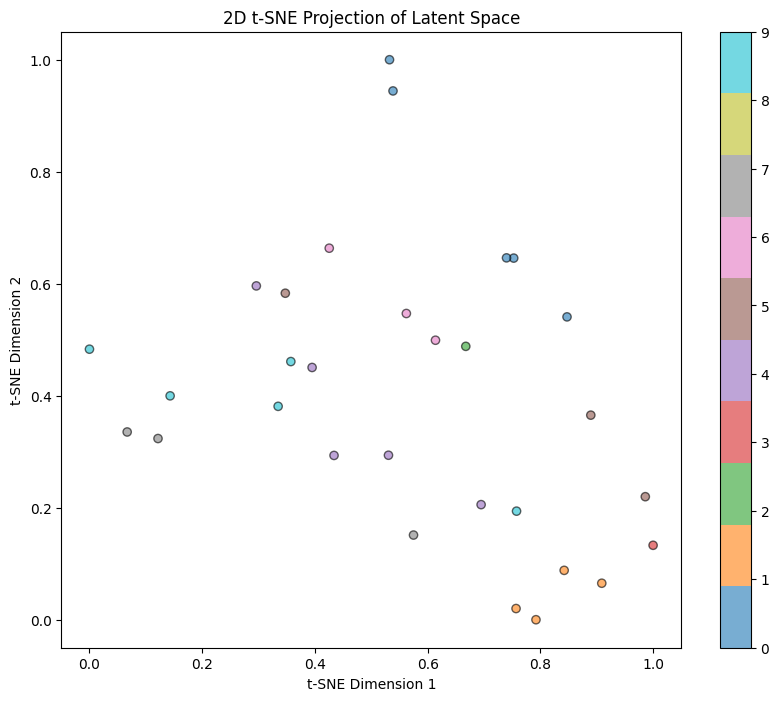

In [10]:
from sklearn.manifold import TSNE
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

# Extract latent representations
model.eval()
num_batches = 3

with torch.no_grad():
    latent_space = []
    labels = []
    batch_count = 0  # Initialize batch counter
    
    for images, digit_labels in test_loader:
        if num_batches is not None and batch_count >= num_batches:
            break  # Stop if the specified number of batches is processed
            
        images = images.to(device)
        latents = model.get_latent_vector(images).cpu().numpy()
        latent_space.append(latents)
        labels.append(digit_labels.cpu().numpy())
        
        batch_count += 1  # Increment batch counter

    latent_space = np.concatenate(latent_space)
    labels = np.concatenate(labels)
    # latent_2d = latent_space
    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, perplexity=20, n_iter=1000, learning_rate=50, random_state=42)
    latent_2d = tsne.fit_transform(latent_space)
    normalized_latent_2D = (latent_2d - np.min(latent_2d, axis=0)) / (np.max(latent_2d, axis=0) - np.min(latent_2d, axis=0))

    # Visualize the latent space
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(normalized_latent_2D[:, 0], normalized_latent_2D[:, 1], c=labels, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.colorbar(scatter)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.title('2D t-SNE Projection of Latent Space')
    plt.show()

0.1112261414527893 0.08056927472352982 0.08056927472352982


D:\documents\python_projects\bulding_ML_models\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([10, 784])) that is different to the input size (torch.Size([784])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


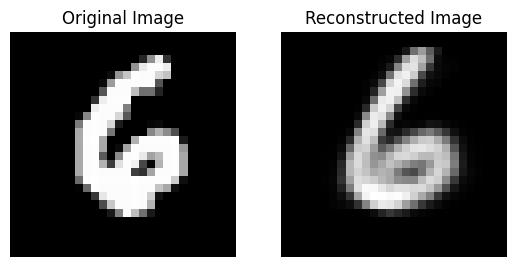

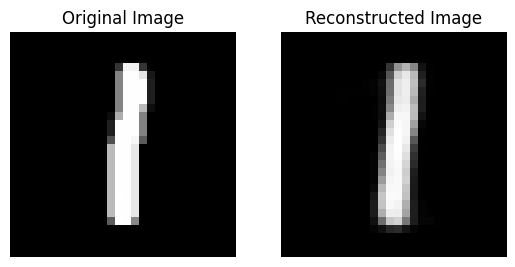

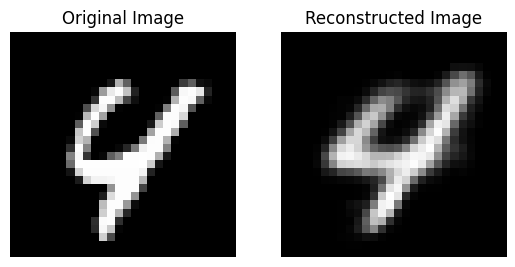

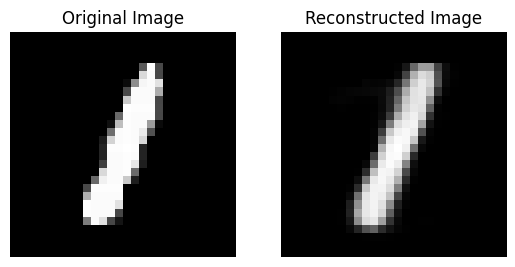

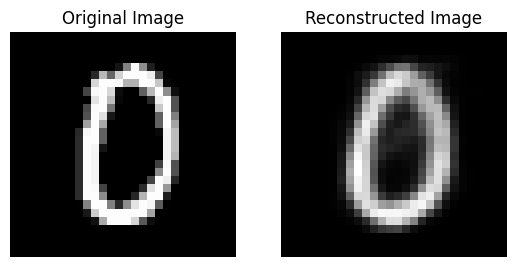

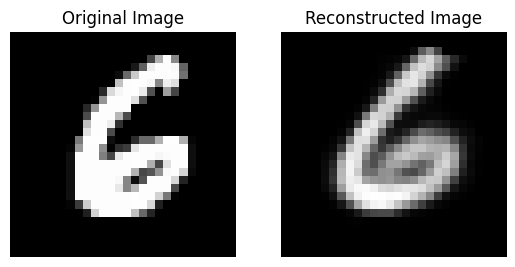

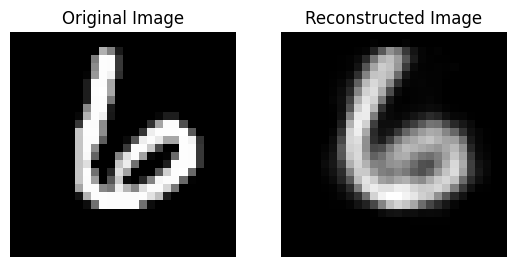

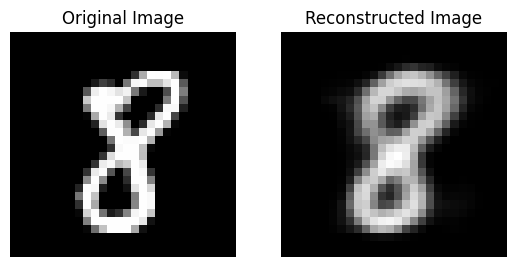

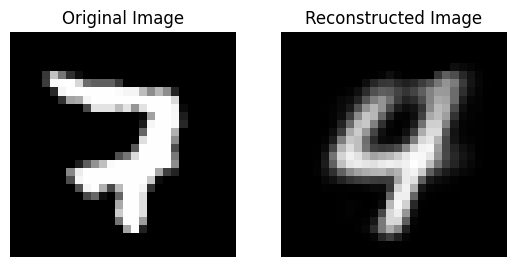

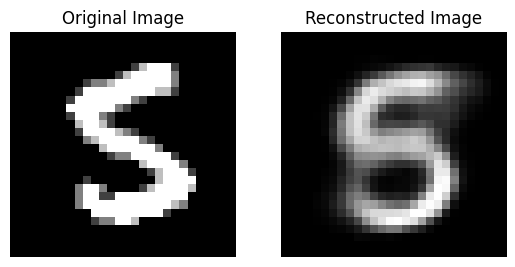

In [11]:
model.eval()
batch_index = 13

with torch.no_grad():
    latent_space = []
    labels = []
    batch_count = 0  # Initialize batch counter
    
    for images, digit_labels in test_loader:
        if batch_count == batch_index:
            images = images.to(device)
            recons = model(images)
            
            mses = []
            
            for img in images:
                mse = criterion(img, recons)
                mses.append(mse.item())
            
            highest_indices = np.argsort(mses)[-10:]
            
            print(max(mses), min(mses), mses[highest_indices[0]])
            for i in highest_indices:
                img = images[i].cpu().numpy()
                recons_img = recons[i].cpu().numpy()
                plt.figure()
                plt.subplot(1, 2, 1)
                plt.imshow(img.reshape(28, 28), cmap='gray')
                plt.title('Original Image')
                plt.axis('off')
                plt.subplot(1, 2, 2)
                plt.imshow(recons_img.reshape(28, 28), cmap='gray')
                plt.title('Reconstructed Image')
                plt.axis('off')
                plt.show()
            
            # plt.imsave("./images/missreconstructions/image_2.png",images[highest_indices[9]].cpu().numpy().reshape(28, 28), cmap='gray')
            # plt.imsave("./images/missreconstructions/recon_2.png",recons[highest_indices[9]].cpu().numpy().reshape(28, 28), cmap='gray')
        batch_count += 1